<a href="https://colab.research.google.com/github/Madankk-06/Generative_AI_Projects/blob/main/4_Hierarchical_Navigable_Small_World_(HNSW)_Vector_Indexing_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import random

In [3]:
np.random.seed(42)

NUM_POINTS = 300
DIM = 64

vectors = np.random.rand(NUM_POINTS, DIM)

print(vectors.shape)

(300, 64)


In [4]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [5]:
class LayerGenerator:

    def __init__(self, max_layer=5):

        self.max_layer = max_layer

    def generate(self):

        layer = 0

        while random.random() < 0.5 and layer < self.max_layer:

            layer += 1

        return layer


generator = LayerGenerator()

layers = [generator.generate() for _ in range(NUM_POINTS)]

print(layers[:20])

[3, 0, 1, 1, 1, 0, 0, 2, 2, 0, 5, 0, 2, 2, 4, 0, 0, 0, 0, 0]


In [6]:
class HNSW:

    def __init__(self, M=5):

        self.M = M
        self.layers = {}
        self.vectors = []

    def add_vector(self, vector, level):

        idx = len(self.vectors)

        self.vectors.append(vector)

        for l in range(level + 1):

            if l not in self.layers:

                self.layers[l] = nx.Graph()

            self.layers[l].add_node(idx)

            self.connect(idx, l)

    def connect(self, idx, layer):

        graph = self.layers[layer]

        nodes = list(graph.nodes)

        if len(nodes) <= 1:

            return

        similarities = []

        for node in nodes:

            if node == idx:

                continue

            sim = cosine_similarity(

                self.vectors[idx],

                self.vectors[node]

            )

            similarities.append((node, sim))

        similarities.sort(key=lambda x: x[1], reverse=True)

        for neighbour, _ in similarities[:self.M]:

            graph.add_edge(idx, neighbour)

In [7]:
class HNSW:

    def __init__(self, M=5):

        self.M = M
        self.layers = {}
        self.vectors = []

    def add_vector(self, vector, level):

        idx = len(self.vectors)

        self.vectors.append(vector)

        for l in range(level + 1):

            if l not in self.layers:

                self.layers[l] = nx.Graph()

            self.layers[l].add_node(idx)

            self.connect(idx, l)

    def connect(self, idx, layer):

        graph = self.layers[layer]

        nodes = list(graph.nodes)

        if len(nodes) <= 1:

            return

        similarities = []

        for node in nodes:

            if node == idx:

                continue

            sim = cosine_similarity(

                self.vectors[idx],

                self.vectors[node]

            )

            similarities.append((node, sim))

        similarities.sort(key=lambda x: x[1], reverse=True)

        for neighbour, _ in similarities[:self.M]:

            graph.add_edge(idx, neighbour)

In [8]:
index = HNSW(M=5)

for vector, level in zip(vectors, layers):

    index.add_vector(vector, level)

print("Layers Created:", len(index.layers))

for layer in index.layers:

    print(layer, index.layers[layer].number_of_nodes())

Layers Created: 6
0 300
1 151
2 71
3 38
4 24
5 14


In [9]:
def search(index, query, top_k=5):

    scores = []

    for i, vector in enumerate(index.vectors):

        sim = cosine_similarity(query, vector)

        scores.append((i, sim))

    scores.sort(key=lambda x: x[1], reverse=True)

    return scores[:top_k]

In [10]:
query = np.random.rand(DIM)

results = search(index, query)

print("Top Results")

for idx, score in results:

    print(idx, round(score,4))

Top Results
10 0.8317
269 0.818
144 0.8156
231 0.8138
145 0.8071


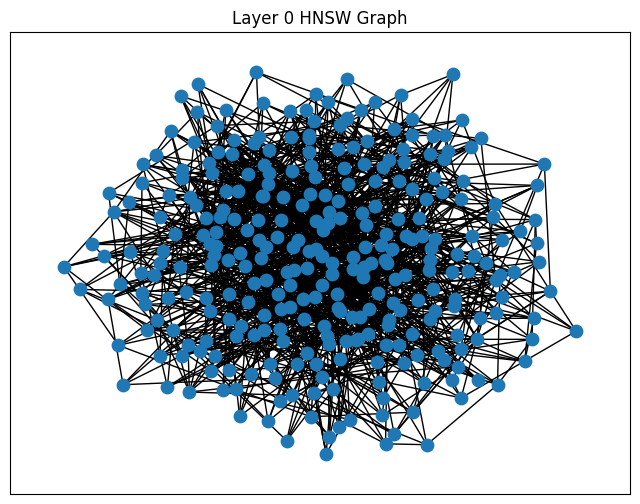

In [11]:
plt.figure(figsize=(8,6))

graph = index.layers[0]

pos = nx.spring_layout(graph, seed=42)

nx.draw_networkx(
    graph,
    pos,
    node_size=80,
    with_labels=False
)

plt.title("Layer 0 HNSW Graph")
plt.show()

In [12]:
print("Graph Statistics\n")

for layer in sorted(index.layers):

    g = index.layers[layer]

    print(f"Layer {layer}")

    print("Nodes :", g.number_of_nodes())

    print("Edges :", g.number_of_edges())

    print("-"*30)

Graph Statistics

Layer 0
Nodes : 300
Edges : 1485
------------------------------
Layer 1
Nodes : 151
Edges : 740
------------------------------
Layer 2
Nodes : 71
Edges : 340
------------------------------
Layer 3
Nodes : 38
Edges : 175
------------------------------
Layer 4
Nodes : 24
Edges : 105
------------------------------
Layer 5
Nodes : 14
Edges : 55
------------------------------


In [13]:
N = len(index.vectors)

print("Approximate Complexity")

print(f"Construction : O(N log N)")

print(f"Search : O(log N)")

print(f"Memory : O(MN)")

Approximate Complexity
Construction : O(N log N)
Search : O(log N)
Memory : O(MN)
